The notebook uses the `DATABASE` dataset to compare four methods:

1. **PPG FFT baseline:** PPG1/PPG2 signals are bandpass filtered from 0.4 to 4 Hz, normalized by z-score, averaged, and then the heart rate is estimated using the main peak via FFT.

2. **ACC-NLMS FFT:** Using the ACC triaxial axis as the reference signal, motion-related artifacts are removed through NLMS adaptive filtering, and then the heart rate is estimated using FFT.

3. **Temko WFPV:** The online WFPV method from the Temko paper and Matlab code `PPG_WFPV_TBME2017.m` is reproduced, which uses Wiener filter + phase vocoder + history-constrained tracking. 4. **Temko WFPV-VD offline**: Reproduces the offline Viterbi decoding version in `PPG_WFPV_VD_TBME2017_offline.m`, serving as a reference for non-real-time offline upper limits.

Outputs:

- Metric tables for `avAE`, `avRE`, and `sdAE`;

- Separate metric tables and graphs for Temko WFPV online and WFPV-VD offline;

- Ultimate comparison table of PPG FFT, ACC-NLMS FFT, Temko WFPV online, and Temko WFPV-VD offline;

- Raw PPG, baseline preprocessed PPG, ACC-NLMS cleaned PPG, and NLMS artifact graphs;

- Time series graphs, correlation graphs, and Bland-Altman graphs for the four methods and `BPM0` golden heart rate.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

WORKSPACE = Path("/Users/xiongzaizai/Documents/PPG")
SCRIPTS = WORKSPACE / "scripts"
DATA_DIR = Path("/Users/xiongzaizai/PPG/DATABASE")
PPG_MASTER = Path("/Users/xiongzaizai/Downloads/PPG-master")
OUTDIR = WORKSPACE / "outputs_ppg_denoising_notebook"
PLOTS_DIR = OUTDIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SCRIPTS))

print("DATABASE:", DATA_DIR, "exists =", DATA_DIR.exists())
print("Temko Matlab code:", PPG_MASTER / "PPG_WFPV_TBME2017.m")
print("Output:", OUTDIR)

DATABASE: /Users/xiongzaizai/PPG/DATABASE exists = True
Temko Matlab code: /Users/xiongzaizai/Downloads/PPG-master/PPG_WFPV_TBME2017.m
Output: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook


## 1. Relationship between Temko Matlab Code and Reproduction in this Paper

In the publicly available Temko paper code:

- `PPG_WFPV_TBME2017.m` is the online HR estimation;

- `PPG_WFPV_VD_TBME2017_offline.m` is the offline Viterbi decoding version.

This paper reproduces two Temko versions:

1. **online WFPV**, corresponding to `PPG_WFPV_TBME2017.m`;

2. **offline WFPV-VD**, corresponding to `PPG_WFPV_VD_TBME2017_offline.m`.

The main steps of online WFPV are:

PPG/ACC band-pass filtering -> PPG channel averaging -> downsample to 25 Hz -> DFT -> Wiener spectral weighting -> phase vocoder frequency refinement -> history-constrained tracking -> BPM0 evaluation.

Offline WFPV-VD first calculates the WFPV emission matrix for the entire recording, then constructs the transition matrix using the BPM0 values ​​from other recordings, and obtains the globally optimal HR trajectory through Viterbi decoding.%它不是实时算法，但很适合作为 Temko 方法的离线性能上限参考。

## 2. Run PPG FFT baseline

In [2]:
env = os.environ.copy()
env["MPLCONFIGDIR"] = str(WORKSPACE / ".mplconfig")

cmd_fft = [
    sys.executable,
    str(SCRIPTS / "ppg_fft_hr_analysis.py"),
    "--data-dir", str(DATA_DIR),
    "--records", "all",
    "--outdir", str(OUTDIR),
    "--window-sec", "8",
    "--step-sec", "2",
    "--n-fft", "4096",
    "--search-low-hz", "0.8",
    "--search-high-hz", "3.0",
    "--ppg-low-hz", "0.4",
    "--ppg-high-hz", "4.0",
    "--smooth-windows", "5",
    "--plot-records", "DATA_01_TYPE01", "DATA_08_TYPE02", "DATA_10_TYPE02", "TEST_S01_T01", "TEST_S07_T02",
]
result = subprocess.run(cmd_fft, cwd=str(WORKSPACE), env=env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout[-5000:])
if result.returncode != 0:
    raise RuntimeError(f"PPG FFT baseline failed with exit code {result.returncode}")

Wrote windows: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ppg_fft_hr_windows.csv
Wrote metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ppg_fft_metrics.csv
Plots:
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_01_TYPE01_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_08_TYPE02_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S01_T01_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S07_T02_timeseries_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/scatter_ppg_fft_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/bland_altman_ppg_fft_vs_bpm0.png
 

## 3. Run ACC-NLMS FFT

In [3]:
cmd_nlms = [
    sys.executable,
    str(SCRIPTS / "ppg_nlms_acc_fft_hr_analysis.py"),
    "--data-dir", str(DATA_DIR),
    "--records", "all",
    "--outdir", str(OUTDIR),
    "--window-sec", "8",
    "--step-sec", "2",
    "--n-fft", "4096",
    "--search-low-hz", "0.8",
    "--search-high-hz", "3.0",
    "--ppg-low-hz", "0.4",
    "--ppg-high-hz", "4.0",
    "--nlms-filter-order", "32",
    "--nlms-mu", "0.005",
    "--smooth-windows", "5",
    "--plot-records", "DATA_01_TYPE01", "DATA_08_TYPE02", "DATA_10_TYPE02", "TEST_S01_T01", "TEST_S07_T02",
]
result = subprocess.run(cmd_nlms, cwd=str(WORKSPACE), env=env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout[-6000:])
if result.returncode != 0:
    raise RuntimeError(f"ACC-NLMS FFT failed with exit code {result.returncode}")

Wrote windows: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ppg_nlms_acc_fft_hr_windows.csv
Wrote metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ppg_nlms_acc_fft_metrics.csv
Wrote NLMS summary: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/nlms_cleaning_summary.csv
Plots:
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_01_TYPE01_timeseries_ppg_fft_nlms_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_08_TYPE02_timeseries_ppg_fft_nlms_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_timeseries_ppg_fft_nlms_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S01_T01_timeseries_ppg_fft_nlms_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S07_T02_timeseries_ppg_fft_nlms_vs_bpm0.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denois

## 4. Run Temko WFPV online method

This unit calls the Python script `temko_wfpv_database_analysis.py`, whose process corresponds to the Matlab file `PPG_WFPV_TBME2017.m`.

In [4]:
cmd_temko = [
    sys.executable,
    str(SCRIPTS / "temko_wfpv_database_analysis.py"),
    "--data-dir", str(DATA_DIR),
    "--records", "all",
    "--outdir", str(OUTDIR),
    "--window-sec", "8",
    "--step-sec", "2",
    "--n-fft", "1024",
    "--search-low-hz", "1.0",
    "--search-high-hz", "3.0",
    "--wf-length", "15",
    "--smooth-freq-bins", "3",
    "--plot-records", "DATA_01_TYPE01", "DATA_08_TYPE02", "DATA_10_TYPE02", "TEST_S01_T01", "TEST_S07_T02",
]
result = subprocess.run(cmd_temko, cwd=str(WORKSPACE), env=env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout[-6000:])
if result.returncode != 0:
    raise RuntimeError(f"Temko WFPV failed with exit code {result.returncode}")

v
Wrote metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/temko_wfpv_database_metrics.csv
Wrote config: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/temko_wfpv_database_config.csv
Plots:
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/mae_by_record_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/scatter_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/bland_altman_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_01_TYPE01_timeseries_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_08_TYPE02_timeseries_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_timeseries_temko_wfpv.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S01_T01_timeseries_temko_wfpv.png
  /Users/xiongzaizai/Docu

## 5. Run the Temko WFPV-VD offline method

This unit calls the Python script `temko_wfpv_vd_database_analysis.py`, whose workflow corresponds to the Matlab file `PPG_WFPV_VD_TBME2017_offline.m`. This method uses the entire record for Viterbi decoding; therefore, the results represent the offline processing performance, not the real-time estimation capability.

In [5]:
cmd_temko_vd = [
    sys.executable,
    str(SCRIPTS / "temko_wfpv_vd_database_analysis.py"),
    "--data-dir", str(DATA_DIR),
    "--records", "all",
    "--outdir", str(OUTDIR),
    "--window-sec", "8",
    "--step-sec", "2",
    "--n-fft", "1024",
    "--search-low-hz", "1.0",
    "--search-high-hz", "3.0",
    "--wf-length", "15",
    "--smooth-freq-bins", "3",
    "--plot-records", "DATA_01_TYPE01", "DATA_08_TYPE02", "DATA_10_TYPE02", "TEST_S01_T01", "TEST_S03_T02", "TEST_S07_T02",
]
result = subprocess.run(cmd_temko_vd, cwd=str(WORKSPACE), env=env, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout[-6000:])
if result.returncode != 0:
    raise RuntimeError(f"Temko WFPV-VD offline failed with exit code {result.returncode}")

izai/Documents/PPG/outputs_ppg_denoising_notebook/temko_wfpv_vd_database_config.csv
Plots:
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/mae_by_record_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/scatter_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/bland_altman_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_01_TYPE01_timeseries_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_08_TYPE02_timeseries_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_timeseries_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S01_T01_timeseries_temko_wfpv_vd.png
  /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/TEST_S03_T02_timeseries_temko_wfpv_vd.png
  /Users/xiongzaizai/Documen

## 6. avAE, avRE, sdAE Indicator Table

Indicator Definitions:

- `avAE`: Average absolute error, unit bpm;

- `avRE`: Average relative absolute error, unit %%;

- `sdAE`: Standard deviation of absolute error, unit bpm.

In [6]:
fft_windows = pd.read_csv(OUTDIR / "ppg_fft_hr_windows.csv")
fft_metrics = pd.read_csv(OUTDIR / "ppg_fft_metrics.csv")
comparison_windows = pd.read_csv(OUTDIR / "ppg_nlms_acc_fft_hr_windows.csv")
comparison_metrics = pd.read_csv(OUTDIR / "ppg_nlms_acc_fft_metrics.csv")
temko_windows = pd.read_csv(OUTDIR / "temko_wfpv_database_windows.csv")
temko_metrics = pd.read_csv(OUTDIR / "temko_wfpv_database_metrics.csv")
temko_vd_windows = pd.read_csv(OUTDIR / "temko_wfpv_vd_database_windows.csv")
temko_vd_metrics = pd.read_csv(OUTDIR / "temko_wfpv_vd_database_metrics.csv")

temko_metrics = temko_metrics.copy()
temko_metrics.insert(2, "method", "Temko WFPV")
temko_vd_metrics = temko_vd_metrics.copy()
temko_vd_metrics.insert(2, "method", "Temko WFPV-VD offline")

all_metrics = pd.concat(
    [
        comparison_metrics,
        temko_metrics,
        temko_vd_metrics,
    ],
    ignore_index=True,
    sort=False,
)

metric_table = all_metrics.loc[
    all_metrics["record"].str.startswith("ALL_"),
    ["record", "split", "method", "n_valid", "mae_bpm", "mean_relative_error_percent", "std_abs_error_bpm", "pearson_r"],
].copy()
metric_table = metric_table.rename(columns={
    "mae_bpm": "avAE_bpm",
    "mean_relative_error_percent": "avRE_percent",
    "std_abs_error_bpm": "sdAE_bpm",
})
metric_table = metric_table.round({
    "avAE_bpm": 3,
    "avRE_percent": 3,
    "sdAE_bpm": 3,
    "pearson_r": 3,
})
metric_table.to_csv(OUTDIR / "four_methods_avAE_avRE_sdAE_table.csv", index=False)
display(metric_table)
print("Saved:", OUTDIR / "four_methods_avAE_avRE_sdAE_table.csv")

,record,split,method,n_valid,avAE_bpm,avRE_percent,sdAE_bpm,pearson_r
44,ALL_training,training,PPG FFT,1768,10.504,7.833,15.551,0.720
45,ALL_training,training,ACC-NLMS FFT,1768,4.207,3.293,7.530,0.938
46,ALL_competition,competition,PPG FFT,1328,15.167,13.131,17.003,0.717
47,ALL_competition,competition,ACC-NLMS FFT,1328,9.652,8.882,13.603,0.848
48,ALL_DATABASE,all,PPG FFT,3096,12.504,10.105,16.350,0.756
49,ALL_DATABASE,all,ACC-NLMS FFT,3096,6.543,5.691,10.908,0.903
72,ALL_training,training,Temko WFPV,1768,1.019,0.806,1.436,0.997
73,ALL_competition,competition,Temko WFPV,1328,4.152,3.740,8.582,0.954
74,ALL_DATABASE,all,Temko WFPV,3096,2.363,2.065,5.930,0.977
97,ALL_training,training,Temko WFPV-VD offline,1768,0.660,0.556,1.192,0.998


Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/four_methods_avAE_avRE_sdAE_table.csv


## 7. Final Table: Comparison of Four Methods

This table provides a direct comparison of PPG FFT, ACC-NLMS FFT, Temko WFPV online, and Temko WFPV-VD offline, and marks the method with the lowest `avAE` for each data partition.

In [7]:
method_order = ["PPG FFT", "ACC-NLMS FFT", "Temko WFPV", "Temko WFPV-VD offline"]
rows = []
for record_name in ["ALL_training", "ALL_competition", "ALL_DATABASE"]:
    subset = metric_table[metric_table["record"] == record_name].copy()
    row = {
        "record": record_name,
        "split": subset["split"].iloc[0],
    }
    for method in method_order:
        m = subset[subset["method"] == method].iloc[0]
        key = method.replace("-", "_").replace(" ", "_")
        row[f"{key}_avAE_bpm"] = float(m["avAE_bpm"])
        row[f"{key}_avRE_percent"] = float(m["avRE_percent"])
        row[f"{key}_sdAE_bpm"] = float(m["sdAE_bpm"])
        row[f"{key}_pearson_r"] = float(m["pearson_r"])
    best = subset.loc[subset["avAE_bpm"].idxmin()]
    row["best_method_by_avAE"] = best["method"]
    row["best_avAE_bpm"] = float(best["avAE_bpm"])
    rows.append(row)

ultimate_table = pd.DataFrame(rows).round(3)
ultimate_table.to_csv(OUTDIR / "ultimate_four_method_comparison_table.csv", index=False)
display(ultimate_table)
print("Saved:", OUTDIR / "ultimate_four_method_comparison_table.csv")

,record,split,PPG_FFT_avAE_bpm,PPG_FFT_avRE_percent,PPG_FFT_sdAE_bpm,PPG_FFT_pearson_r,ACC_NLMS_FFT_avAE_bpm,ACC_NLMS_FFT_avRE_percent,ACC_NLMS_FFT_sdAE_bpm,ACC_NLMS_FFT_pearson_r,Temko_WFPV_avAE_bpm,Temko_WFPV_avRE_percent,Temko_WFPV_sdAE_bpm,Temko_WFPV_pearson_r,Temko_WFPV_VD_offline_avAE_bpm,Temko_WFPV_VD_offline_avRE_percent,Temko_WFPV_VD_offline_sdAE_bpm,Temko_WFPV_VD_offline_pearson_r,best_method_by_avAE,best_avAE_bpm
0,ALL_training,training,10.504,7.833,15.551,0.720,4.207,3.293,7.530,0.938,1.019,0.806,1.436,0.997,0.660,0.556,1.192,0.998,Temko WFPV-VD offline,0.660
1,ALL_competition,competition,15.167,13.131,17.003,0.717,9.652,8.882,13.603,0.848,4.152,3.740,8.582,0.954,2.173,2.184,4.260,0.989,Temko WFPV-VD offline,2.173
2,ALL_DATABASE,all,12.504,10.105,16.350,0.756,6.543,5.691,10.908,0.903,2.363,2.065,5.930,0.977,1.309,1.254,3.026,0.994,Temko WFPV-VD offline,1.309


Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ultimate_four_method_comparison_table.csv


## 8. Raw PPG, Baseline Preprocessed PPG, and ACC-NLMS Cleaned PPG

Here, we select a window with noticeable motion artifacts from `DATA_10_TYPE02` to display the following within the same time period:

1. Unprocessed PPG1/PPG2 average signal;

2. Baseline preprocessed PPG;

3. ACC-NLMS cleaned PPG;

4. ACC-correlated artifact estimated by NLMS.

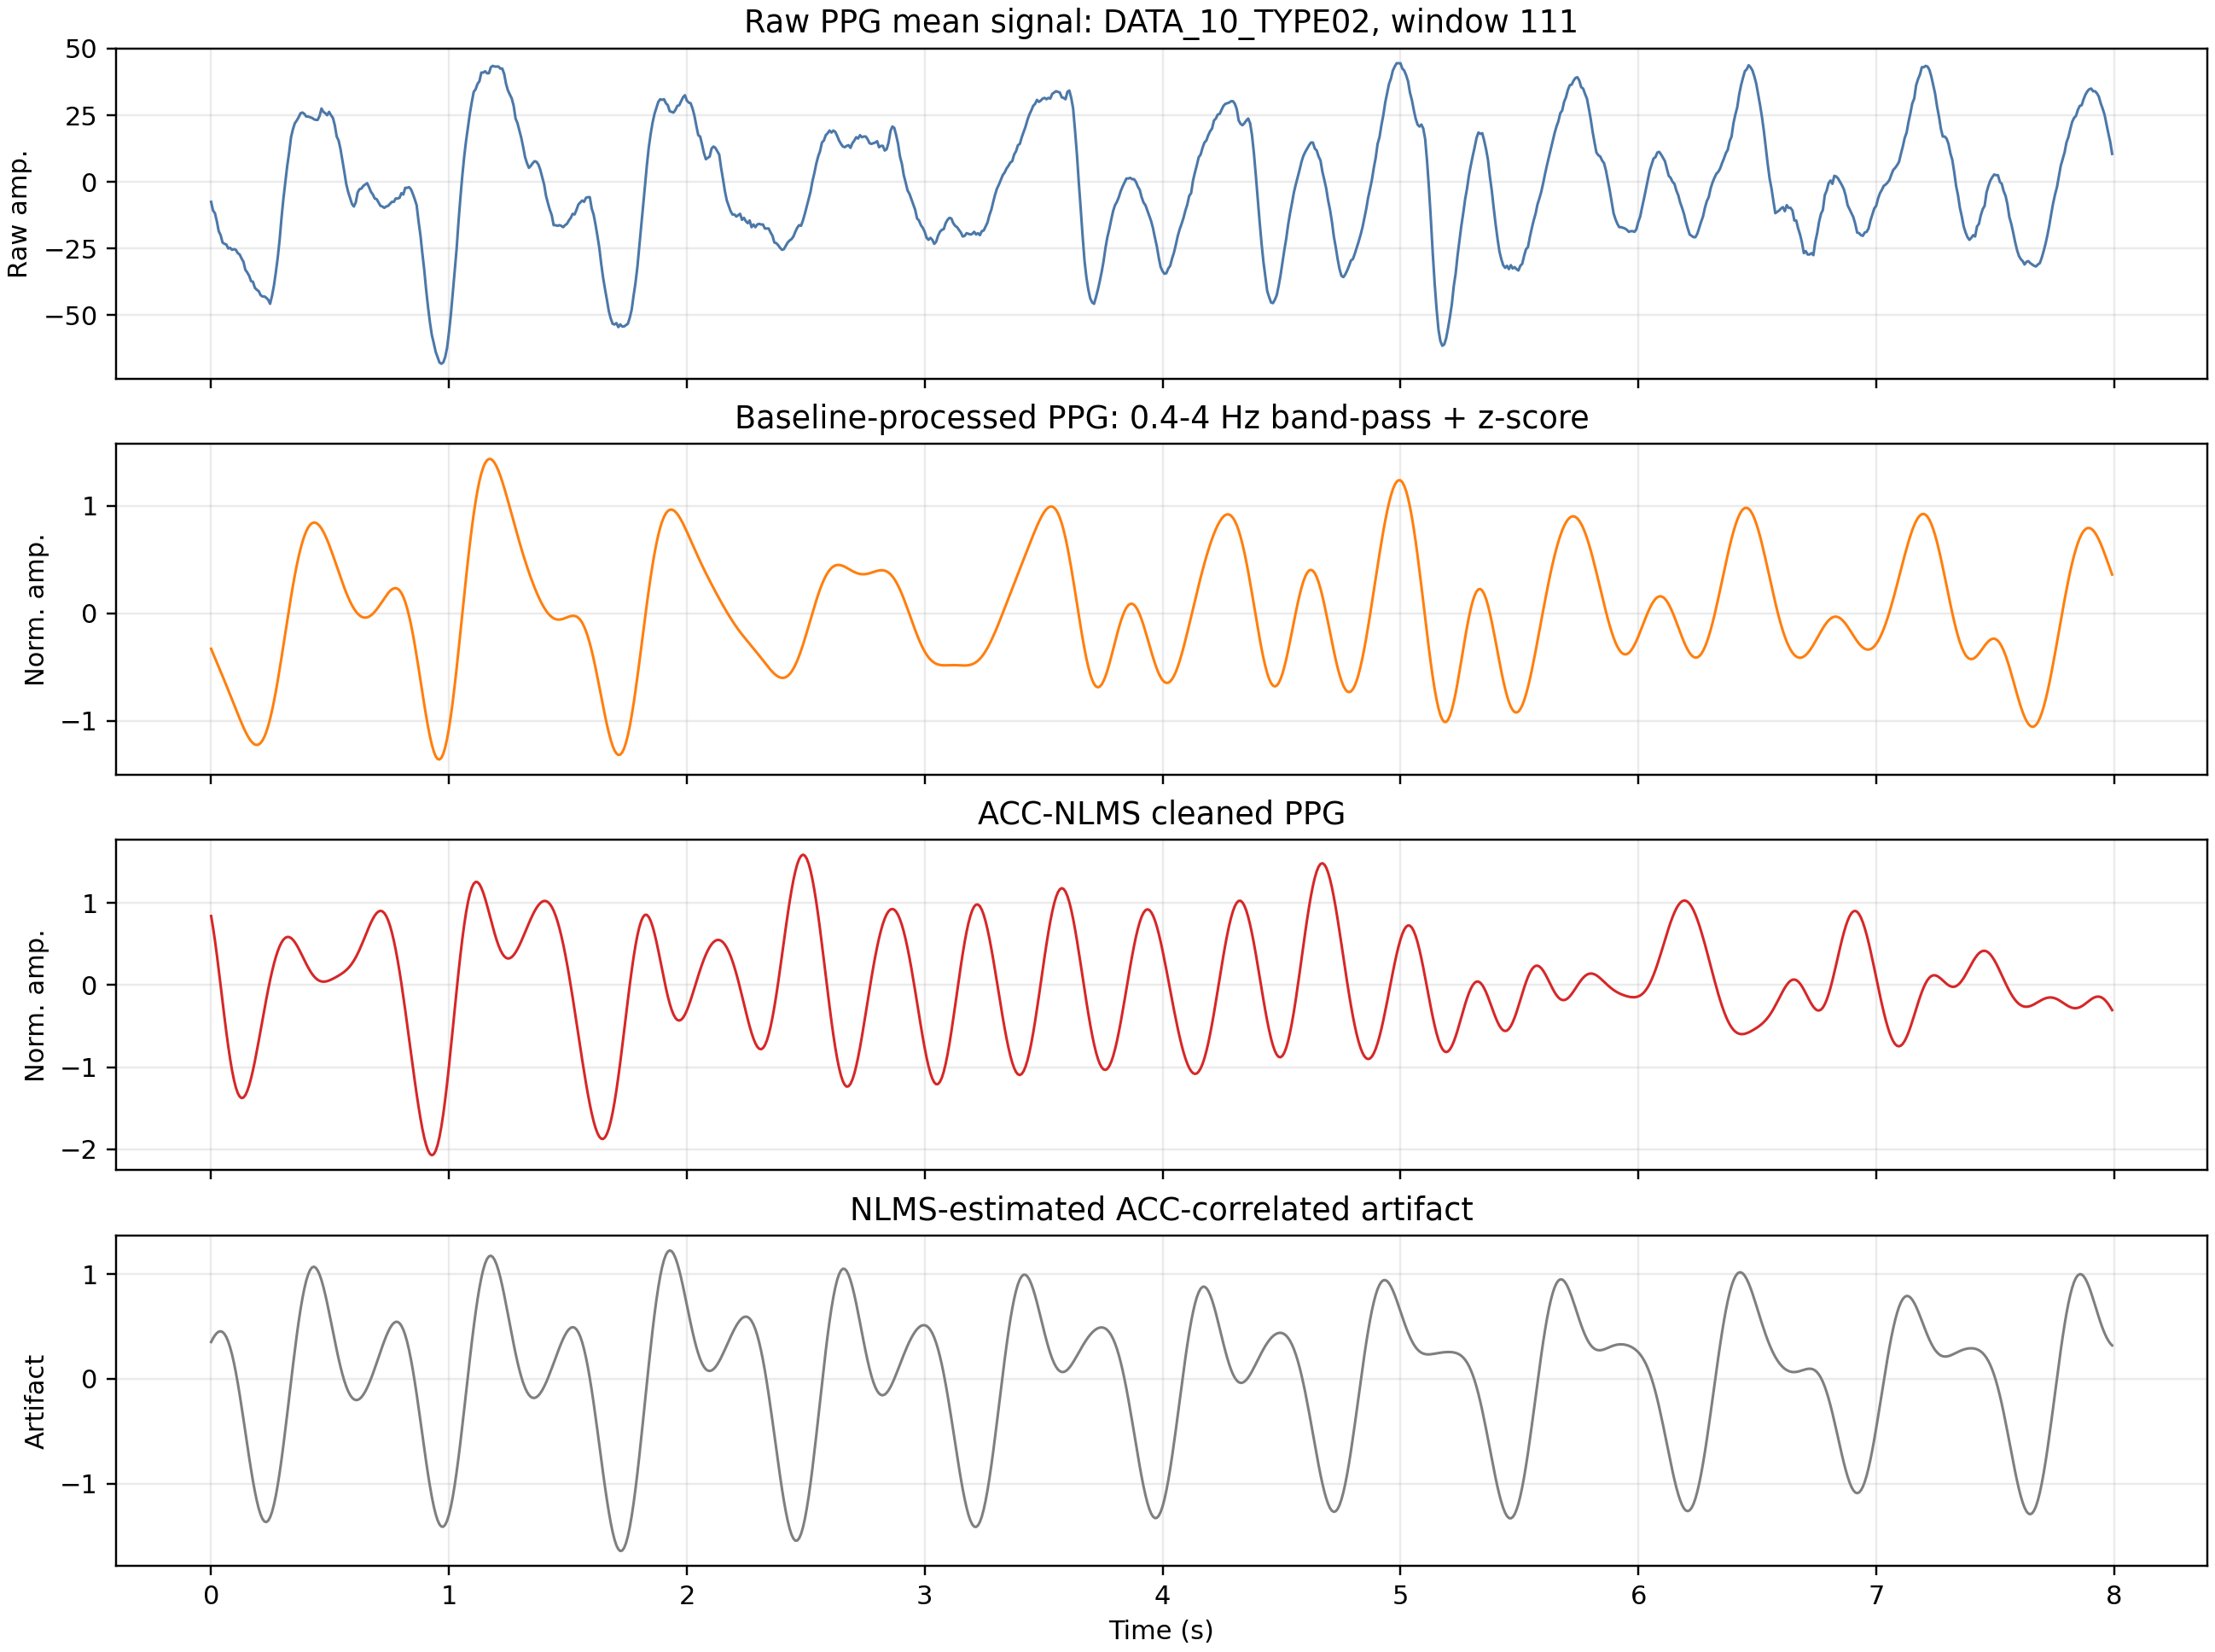

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_raw_baseline_processed_acc_nlms_cleaned.png


In [8]:
from ppg_fft_hr_analysis import (
    discover_records,
    load_record,
    extract_ppg_channels,
    preprocess_ppg_window,
)
from ppg_nlms_acc_fft_hr_analysis import make_nlms_cleaned_ppg

DEMO_RECORD = "DATA_10_TYPE02"
DEMO_WINDOW_INDEX = 111
FS = 125.0
WINDOW_SEC = 8.0
STEP_SEC = 2.0

record_map = {record.name: record for record in discover_records(DATA_DIR, ["all"])}
record = record_map[DEMO_RECORD]
sig, bpm0 = load_record(record)
ppg1, ppg2 = extract_ppg_channels(record, sig)

desired, cleaned, artifact = make_nlms_cleaned_ppg(
    record,
    sig,
    fs=FS,
    ppg_low_hz=0.4,
    ppg_high_hz=4.0,
    filter_order=4,
    nlms_filter_order=32,
    nlms_mu=0.005,
    nlms_eps=1e-6,
)

window_pts = int(round(WINDOW_SEC * FS))
step_pts = int(round(STEP_SEC * FS))
start = (DEMO_WINDOW_INDEX - 1) * step_pts
stop = start + window_pts
t = np.arange(window_pts) / FS

raw_ppg = 0.5 * ppg1[start:stop] + 0.5 * ppg2[start:stop]
ppg1_processed = preprocess_ppg_window(ppg1[start:stop], FS, low_hz=0.4, high_hz=4.0, order=4)
ppg2_processed = preprocess_ppg_window(ppg2[start:stop], FS, low_hz=0.4, high_hz=4.0, order=4)
baseline_processed = 0.5 * ppg1_processed + 0.5 * ppg2_processed

fig, axes = plt.subplots(4, 1, figsize=(11.8, 8.8), sharex=True, constrained_layout=True)
axes[0].plot(t, raw_ppg, color="#4c78a8", linewidth=1.0)
axes[0].set_title(f"Raw PPG mean signal: {DEMO_RECORD}, window {DEMO_WINDOW_INDEX}")
axes[0].set_ylabel("Raw amp.")

axes[1].plot(t, baseline_processed, color="#ff7f0e", linewidth=1.0)
axes[1].set_title("Baseline-processed PPG: 0.4-4 Hz band-pass + z-score")
axes[1].set_ylabel("Norm. amp.")

axes[2].plot(t, cleaned[start:stop], color="#d62728", linewidth=1.0)
axes[2].set_title("ACC-NLMS cleaned PPG")
axes[2].set_ylabel("Norm. amp.")

axes[3].plot(t, artifact[start:stop], color="#7f7f7f", linewidth=1.0)
axes[3].set_title("NLMS-estimated ACC-correlated artifact")
axes[3].set_xlabel("Time (s)")
axes[3].set_ylabel("Artifact")

for ax in axes:
    ax.grid(True, alpha=0.25)

signal_path = PLOTS_DIR / f"{DEMO_RECORD}_raw_baseline_processed_acc_nlms_cleaned.png"
fig.savefig(signal_path, dpi=220)
plt.close(fig)

display(Image(filename=str(signal_path), width=920))
print("Saved:", signal_path)

## 9. Merging window-level results from four methods

In [9]:
all_windows = comparison_windows.merge(
    temko_windows[["record", "center_time_s", "temko_wfpv_hr_bpm"]],
    on=["record", "center_time_s"],
    how="left",
).merge(
    temko_vd_windows[["record", "center_time_s", "temko_wfpv_vd_hr_bpm"]],
    on=["record", "center_time_s"],
    how="left",
)
all_windows.to_csv(OUTDIR / "four_methods_window_level_results.csv", index=False)
print("Saved:", OUTDIR / "four_methods_window_level_results.csv")
display(all_windows.head())

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/four_methods_window_level_results.csv


,record,split,fs_hz,window_index,start_time_s,end_time_s,center_time_s,hr_true_bpm,ground_truth_hr_bpm,ppg_fft_peak_hz_raw,...,ppg_acc_nlms_fft_hr_raw_bpm_clean,ppg_acc_nlms_fft_hr_est_bpm,ppg_fft_error_bpm,ppg_fft_abs_error_bpm,ppg_fft_relative_abs_error_percent,acc_nlms_fft_error_bpm,acc_nlms_fft_abs_error_bpm,acc_nlms_fft_relative_abs_error_percent,temko_wfpv_hr_bpm,temko_wfpv_vd_hr_bpm
0,DATA_01_TYPE01,training,125.0,1,0.0,8.0,4.0,74.339207,74.339207,1.220703,...,73.242188,73.242188,-1.097020,1.097020,1.475694,-1.097020,1.097020,1.475694,74.780059,75.388029
1,DATA_01_TYPE01,training,125.0,2,2.0,10.0,6.0,76.357466,76.357466,1.281738,...,76.904297,75.073242,-1.284224,1.284224,1.681858,-1.284224,1.284224,1.681858,74.385878,75.388029
2,DATA_01_TYPE01,training,125.0,3,4.0,12.0,8.0,77.142857,77.142857,1.312256,...,76.904297,75.683594,-0.848912,0.848912,1.100441,-1.459263,1.459263,1.891638,76.280531,75.223056
3,DATA_01_TYPE01,training,125.0,4,6.0,14.0,10.0,74.668142,74.668142,1.281738,...,75.073242,75.531006,1.778392,1.778392,2.381727,0.862864,0.862864,1.155599,75.905647,74.786357
4,DATA_01_TYPE01,training,125.0,5,8.0,16.0,12.0,72.580645,72.580645,1.190186,...,71.411133,74.707031,2.858808,2.858808,3.938802,2.126386,2.126386,2.929688,73.920167,73.777405


## 10. Time Series Comparison with BPM0

This chart shows the time series of `BPM0`, PPG FFT, ACC-NLMS FFT, Temko WFPV online, and Temko WFPV-VD offline in the same record.

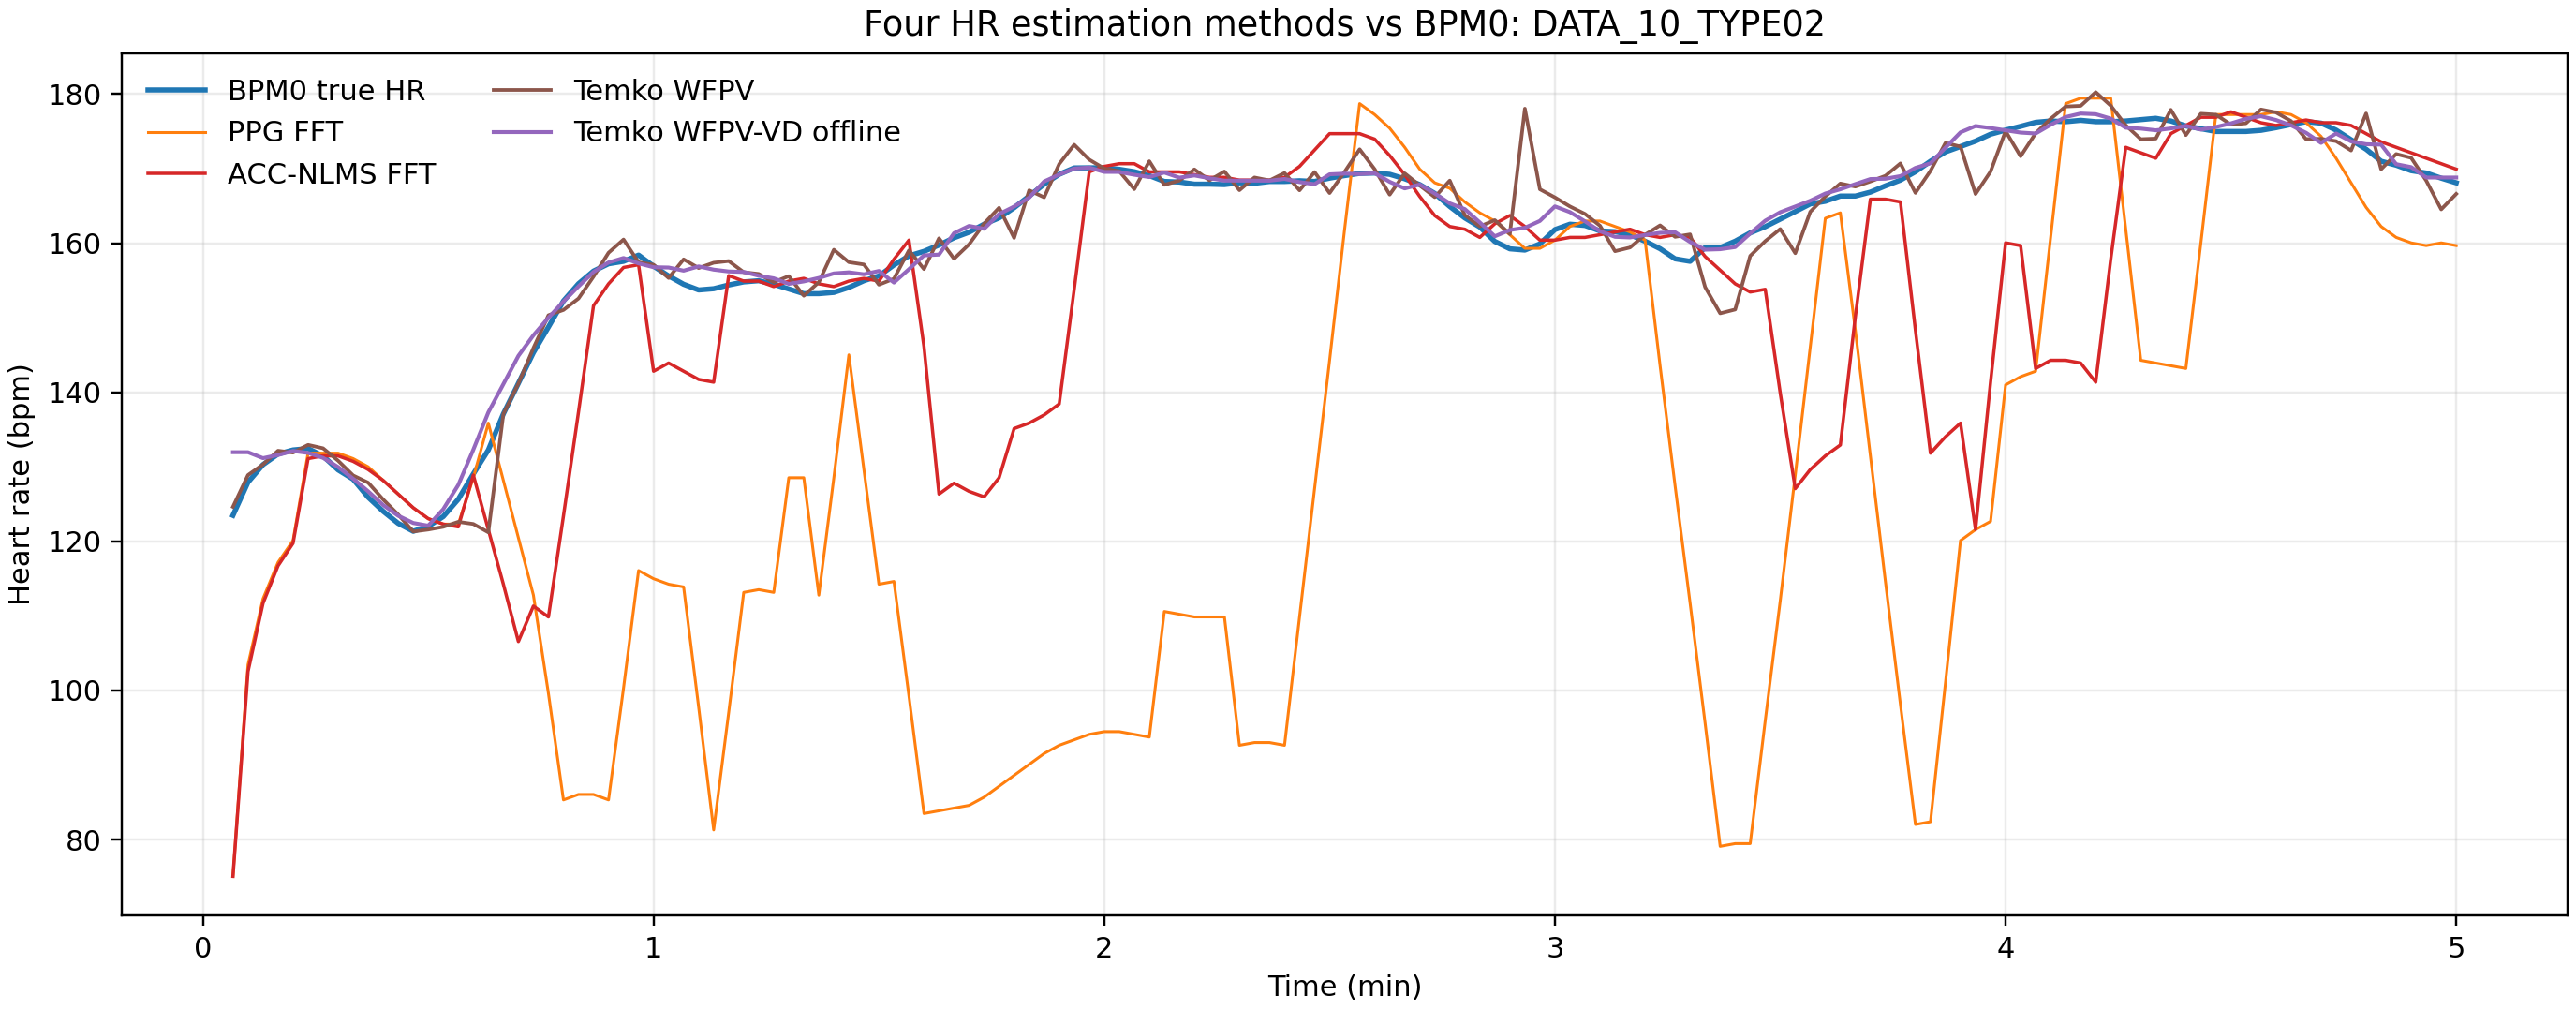

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_hr_true_four_methods.png


In [10]:
PLOT_RECORD = "DATA_10_TYPE02"
record_df = all_windows[all_windows["record"] == PLOT_RECORD].copy()

fig, ax = plt.subplots(figsize=(12.5, 4.9), constrained_layout=True)
ax.plot(record_df["center_time_s"] / 60.0, record_df["hr_true_bpm"], label="BPM0 true HR", color="#1f77b4", linewidth=1.8)
ax.plot(record_df["center_time_s"] / 60.0, record_df["ppg_fft_hr_est_bpm"], label="PPG FFT", color="#ff7f0e", linewidth=1.0)
ax.plot(record_df["center_time_s"] / 60.0, record_df["ppg_acc_nlms_fft_hr_est_bpm"], label="ACC-NLMS FFT", color="#d62728", linewidth=1.15)
ax.plot(record_df["center_time_s"] / 60.0, record_df["temko_wfpv_hr_bpm"], label="Temko WFPV", color="#8c564b", linewidth=1.25)
ax.plot(record_df["center_time_s"] / 60.0, record_df["temko_wfpv_vd_hr_bpm"], label="Temko WFPV-VD offline", color="#9467bd", linewidth=1.35)
ax.set_title(f"Four HR estimation methods vs BPM0: {PLOT_RECORD}")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Heart rate (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, ncol=2)

timeseries_path = PLOTS_DIR / f"{PLOT_RECORD}_hr_true_four_methods.png"
fig.savefig(timeseries_path, dpi=220)
plt.close(fig)

display(Image(filename=str(timeseries_path), width=980))
print("Saved:", timeseries_path)

## 11. Temko WFPV alone and BPM0 comparison chart

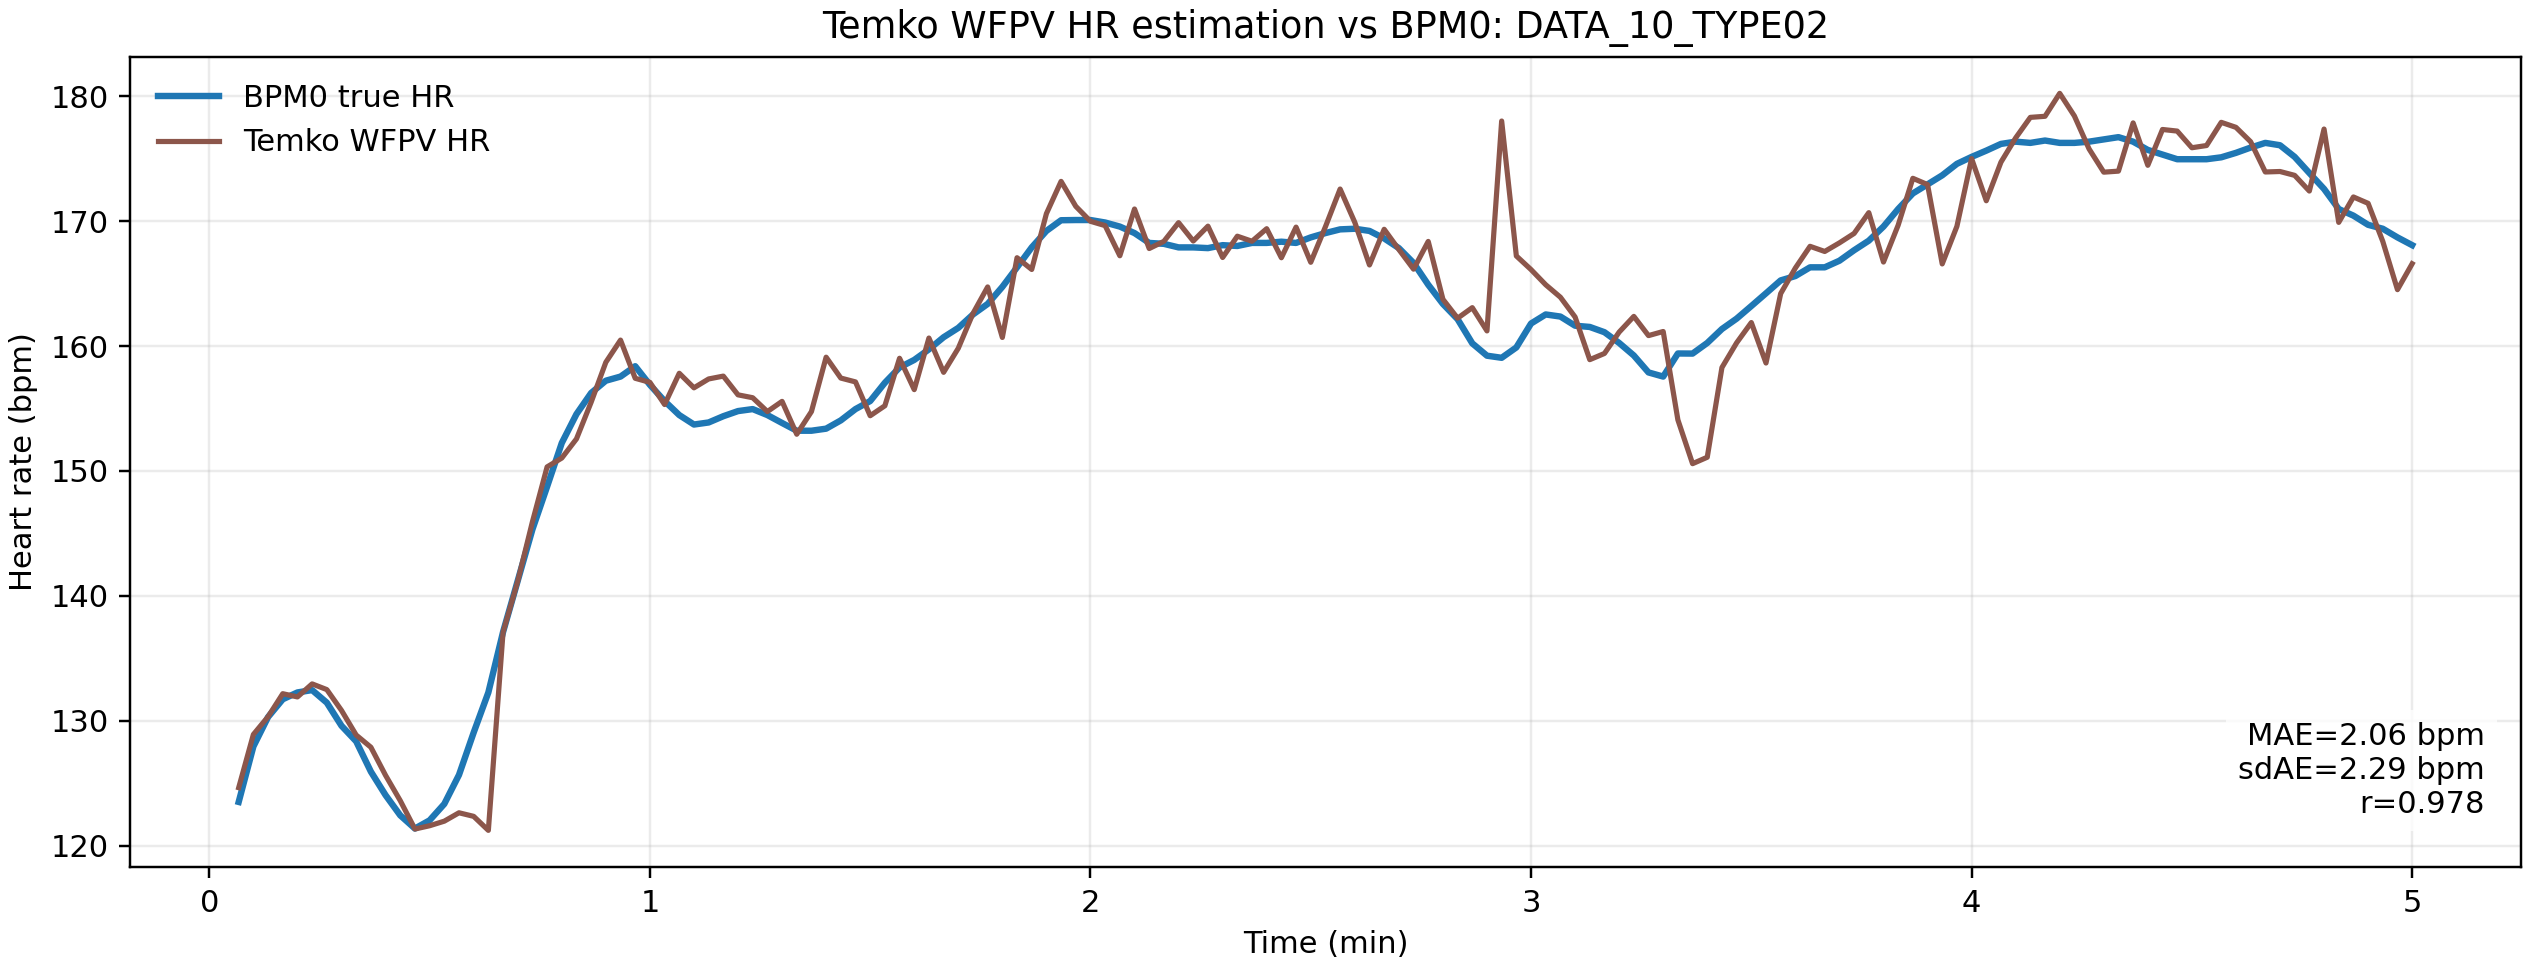

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_temko_wfpv_vs_bpm0_only.png
DATA_10_TYPE02 Temko-only: MAE=2.061 bpm, sdAE=2.295 bpm, r=0.9785


In [11]:
temko_only_df = record_df[["center_time_s", "hr_true_bpm", "temko_wfpv_hr_bpm"]].dropna().copy()
temko_only_error = temko_only_df["temko_wfpv_hr_bpm"] - temko_only_df["hr_true_bpm"]
temko_only_mae = np.mean(np.abs(temko_only_error))
temko_only_sdAE = np.std(np.abs(temko_only_error), ddof=1)
temko_only_r = np.corrcoef(temko_only_df["hr_true_bpm"], temko_only_df["temko_wfpv_hr_bpm"])[0, 1]

fig, ax = plt.subplots(figsize=(11.5, 4.4), constrained_layout=True)
ax.plot(
    temko_only_df["center_time_s"] / 60.0,
    temko_only_df["hr_true_bpm"],
    label="BPM0 true HR",
    color="#1f77b4",
    linewidth=2.1,
)
ax.plot(
    temko_only_df["center_time_s"] / 60.0,
    temko_only_df["temko_wfpv_hr_bpm"],
    label="Temko WFPV HR",
    color="#8c564b",
    linewidth=1.7,
)
ax.set_title(f"Temko WFPV HR estimation vs BPM0: {PLOT_RECORD}")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Heart rate (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")
ax.text(
    0.985,
    0.06,
    f"MAE={temko_only_mae:.2f} bpm\nsdAE={temko_only_sdAE:.2f} bpm\nr={temko_only_r:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 4},
)

temko_only_path = PLOTS_DIR / f"{PLOT_RECORD}_temko_wfpv_vs_bpm0_only.png"
fig.savefig(temko_only_path, dpi=220)
plt.close(fig)

display(Image(filename=str(temko_only_path), width=940))
print("Saved:", temko_only_path)
print(f"{PLOT_RECORD} Temko-only: MAE={temko_only_mae:.3f} bpm, sdAE={temko_only_sdAE:.3f} bpm, r={temko_only_r:.4f}")

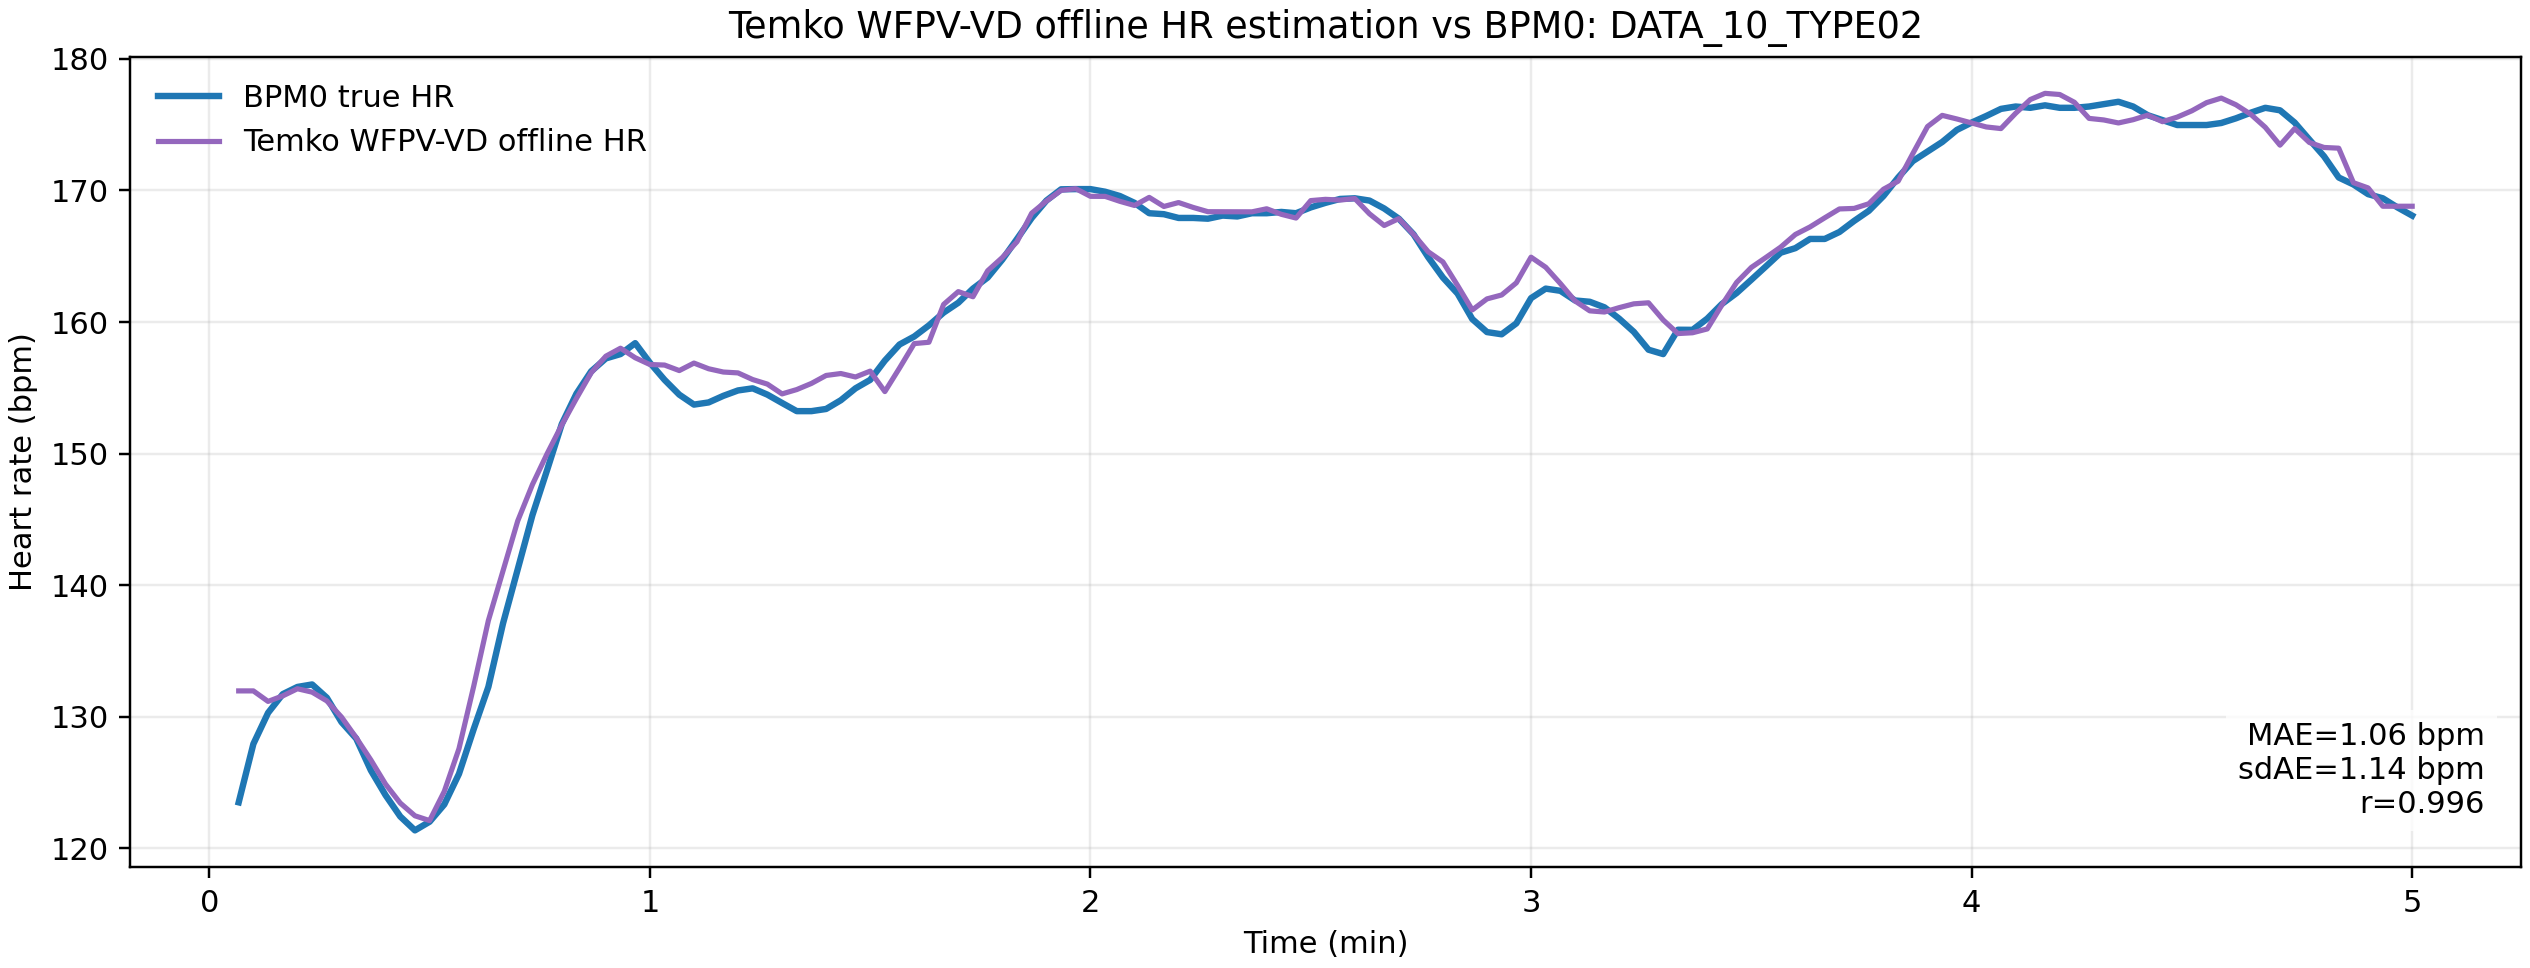

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/DATA_10_TYPE02_temko_wfpv_vd_vs_bpm0_only.png
DATA_10_TYPE02 Temko WFPV-VD offline: MAE=1.063 bpm, sdAE=1.142 bpm, r=0.9957


In [12]:
temko_vd_only_df = record_df[["center_time_s", "hr_true_bpm", "temko_wfpv_vd_hr_bpm"]].dropna().copy()
temko_vd_only_error = temko_vd_only_df["temko_wfpv_vd_hr_bpm"] - temko_vd_only_df["hr_true_bpm"]
temko_vd_only_mae = np.mean(np.abs(temko_vd_only_error))
temko_vd_only_sdAE = np.std(np.abs(temko_vd_only_error), ddof=1)
temko_vd_only_r = np.corrcoef(temko_vd_only_df["hr_true_bpm"], temko_vd_only_df["temko_wfpv_vd_hr_bpm"])[0, 1]

fig, ax = plt.subplots(figsize=(11.5, 4.4), constrained_layout=True)
ax.plot(
    temko_vd_only_df["center_time_s"] / 60.0,
    temko_vd_only_df["hr_true_bpm"],
    label="BPM0 true HR",
    color="#1f77b4",
    linewidth=2.1,
)
ax.plot(
    temko_vd_only_df["center_time_s"] / 60.0,
    temko_vd_only_df["temko_wfpv_vd_hr_bpm"],
    label="Temko WFPV-VD offline HR",
    color="#9467bd",
    linewidth=1.7,
)
ax.set_title(f"Temko WFPV-VD offline HR estimation vs BPM0: {PLOT_RECORD}")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Heart rate (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")
ax.text(
    0.985,
    0.06,
    f"MAE={temko_vd_only_mae:.2f} bpm\nsdAE={temko_vd_only_sdAE:.2f} bpm\nr={temko_vd_only_r:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 4},
)

temko_vd_only_path = PLOTS_DIR / f"{PLOT_RECORD}_temko_wfpv_vd_vs_bpm0_only.png"
fig.savefig(temko_vd_only_path, dpi=220)
plt.close(fig)

display(Image(filename=str(temko_vd_only_path), width=940))
print("Saved:", temko_vd_only_path)
print(f"{PLOT_RECORD} Temko WFPV-VD offline: MAE={temko_vd_only_mae:.3f} bpm, sdAE={temko_vd_only_sdAE:.3f} bpm, r={temko_vd_only_r:.4f}")

## 12. Comparison Chart of Four MAE Methods

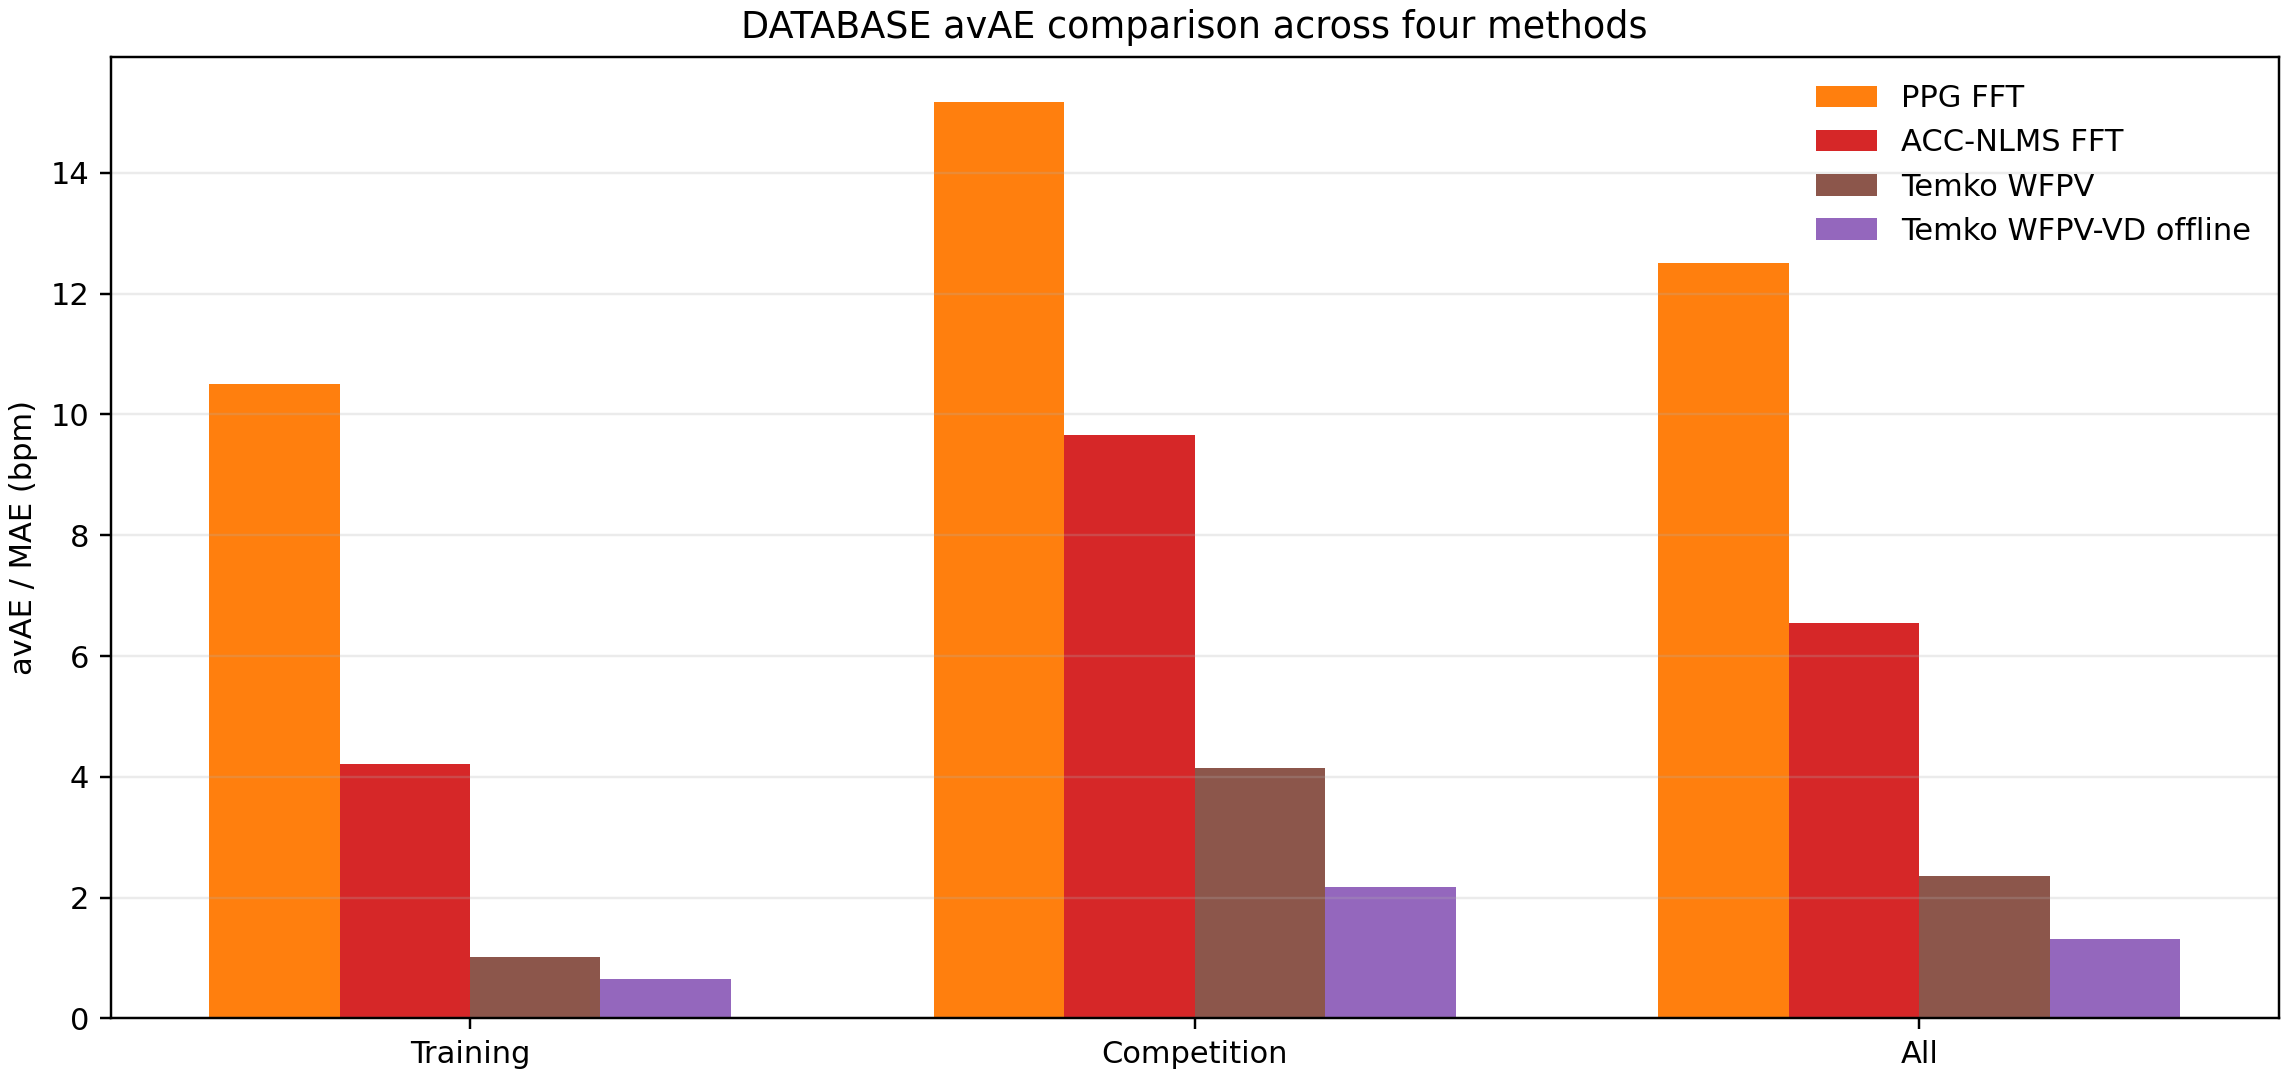

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/mae_four_methods.png


In [13]:
records_for_plot = ["ALL_training", "ALL_competition", "ALL_DATABASE"]
labels_for_plot = ["Training", "Competition", "All"]
colors = {
    "PPG FFT": "#ff7f0e",
    "ACC-NLMS FFT": "#d62728",
    "Temko WFPV": "#8c564b",
    "Temko WFPV-VD offline": "#9467bd",
}
x = np.arange(len(records_for_plot), dtype=float)
width = 0.18

fig, ax = plt.subplots(figsize=(10.4, 4.9), constrained_layout=True)
for i, method in enumerate(method_order):
    values = []
    for record_name in records_for_plot:
        row = metric_table[(metric_table["record"] == record_name) & (metric_table["method"] == method)]
        values.append(float(row["avAE_bpm"].iloc[0]) if not row.empty else np.nan)
    offset = (i - (len(method_order) - 1) / 2.0) * width
    ax.bar(x + offset, values, width=width, color=colors[method], label=method)
ax.set_xticks(x)
ax.set_xticklabels(labels_for_plot)
ax.set_ylabel("avAE / MAE (bpm)")
ax.set_title("DATABASE avAE comparison across four methods")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False)

mae_path = PLOTS_DIR / "mae_four_methods.png"
fig.savefig(mae_path, dpi=220)
plt.close(fig)

display(Image(filename=str(mae_path), width=850))
print("Saved:", mae_path)

## 13. Correlation 图

## 13. Correlation Diagram

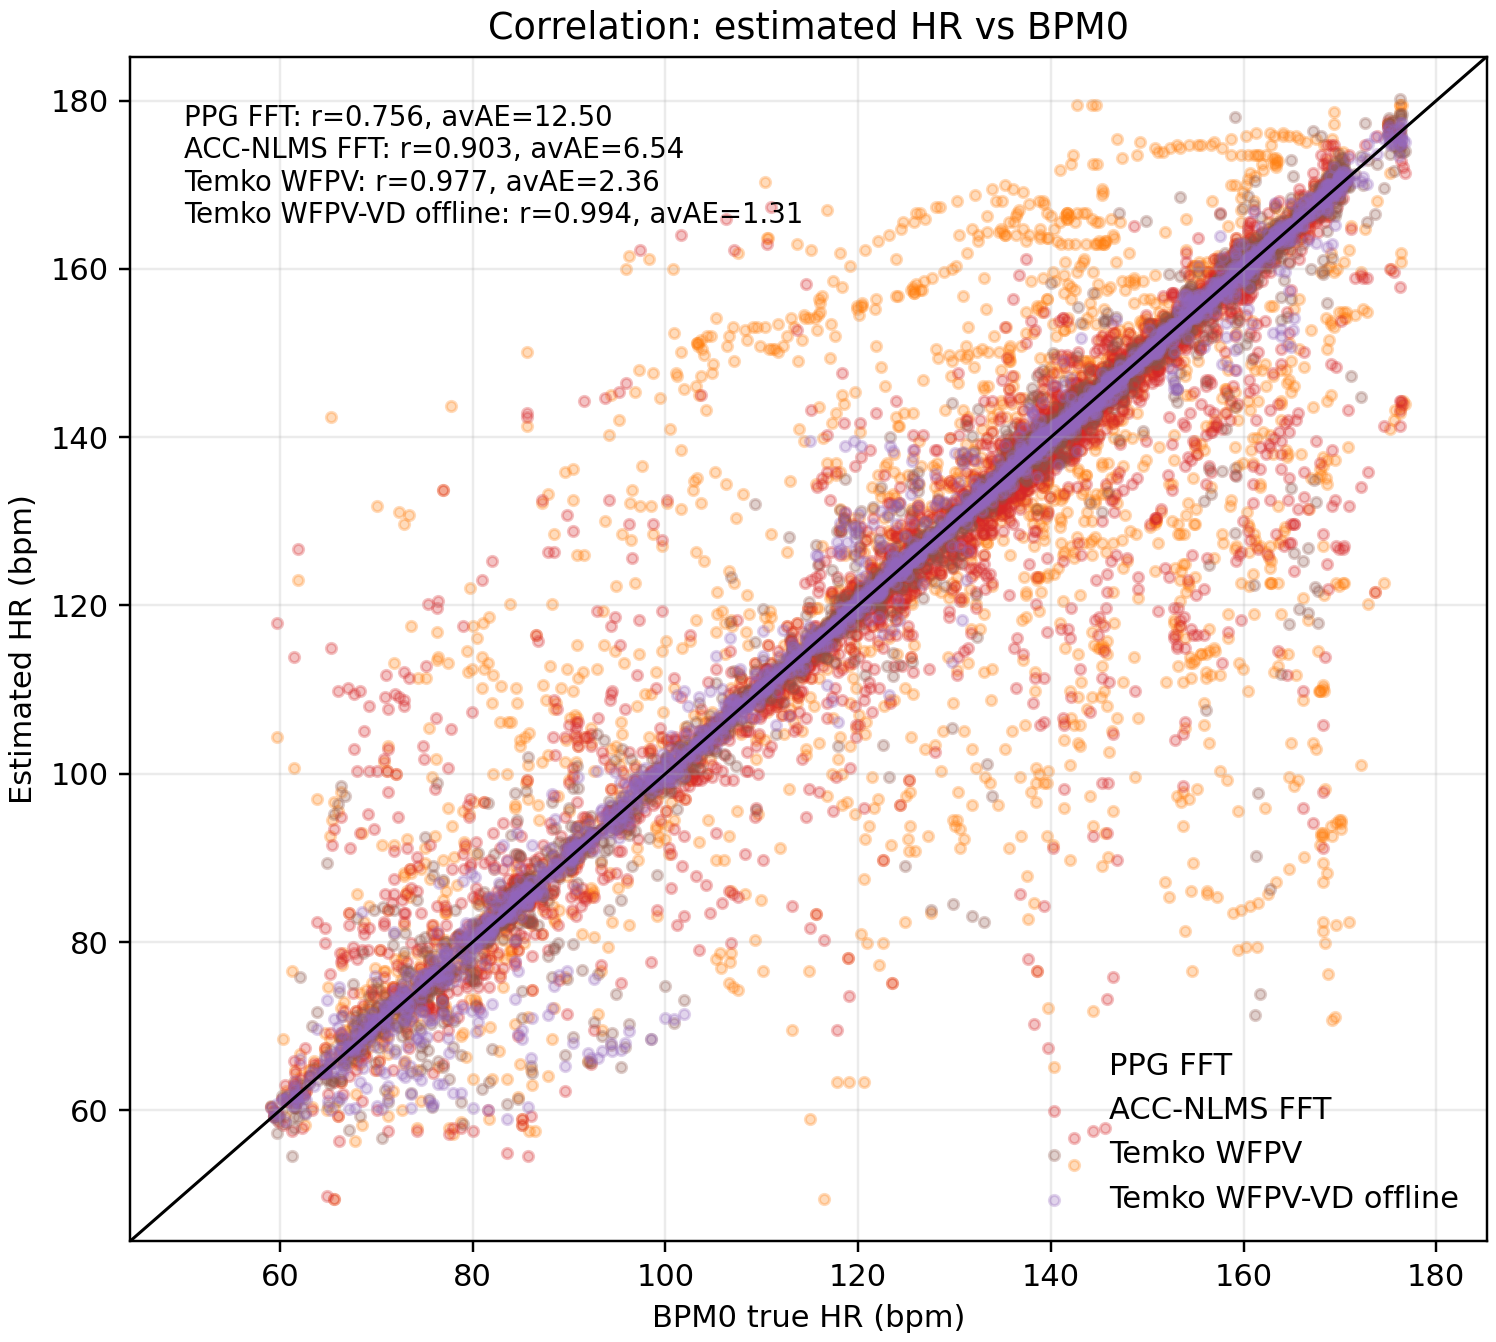

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/correlation_four_methods.png


In [14]:
specs = [
    ("PPG FFT", "ppg_fft_hr_est_bpm", "#ff7f0e"),
    ("ACC-NLMS FFT", "ppg_acc_nlms_fft_hr_est_bpm", "#d62728"),
    ("Temko WFPV", "temko_wfpv_hr_bpm", "#8c564b"),
    ("Temko WFPV-VD offline", "temko_wfpv_vd_hr_bpm", "#9467bd"),
]

fig, ax = plt.subplots(figsize=(6.8, 6.1), constrained_layout=True)
vals = [all_windows["hr_true_bpm"].to_numpy()]
text_lines = []
for method, col, color in specs:
    valid = all_windows[["hr_true_bpm", col]].dropna()
    ax.scatter(valid["hr_true_bpm"], valid[col], s=11, alpha=0.28, label=method, color=color)
    vals.append(valid[col].to_numpy())
    row = metric_table[(metric_table["record"] == "ALL_DATABASE") & (metric_table["method"] == method)].iloc[0]
    text_lines.append(f"{method}: r={row['pearson_r']:.3f}, avAE={row['avAE_bpm']:.2f}")
finite = np.concatenate([v[np.isfinite(v)] for v in vals if v.size])
lo = float(finite.min() - 5)
hi = float(finite.max() + 5)
ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.0)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.text(0.04, 0.96, "\n".join(text_lines), transform=ax.transAxes, va="top", fontsize=9)
ax.set_title("Correlation: estimated HR vs BPM0")
ax.set_xlabel("BPM0 true HR (bpm)")
ax.set_ylabel("Estimated HR (bpm)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="lower right")

corr_path = PLOTS_DIR / "correlation_four_methods.png"
fig.savefig(corr_path, dpi=220)
plt.close(fig)

display(Image(filename=str(corr_path), width=760))
print("Saved:", corr_path)

## 14. Bland-Altman Plot

This plot compares the consistency and error distribution of the four methods relative to `BPM0`.

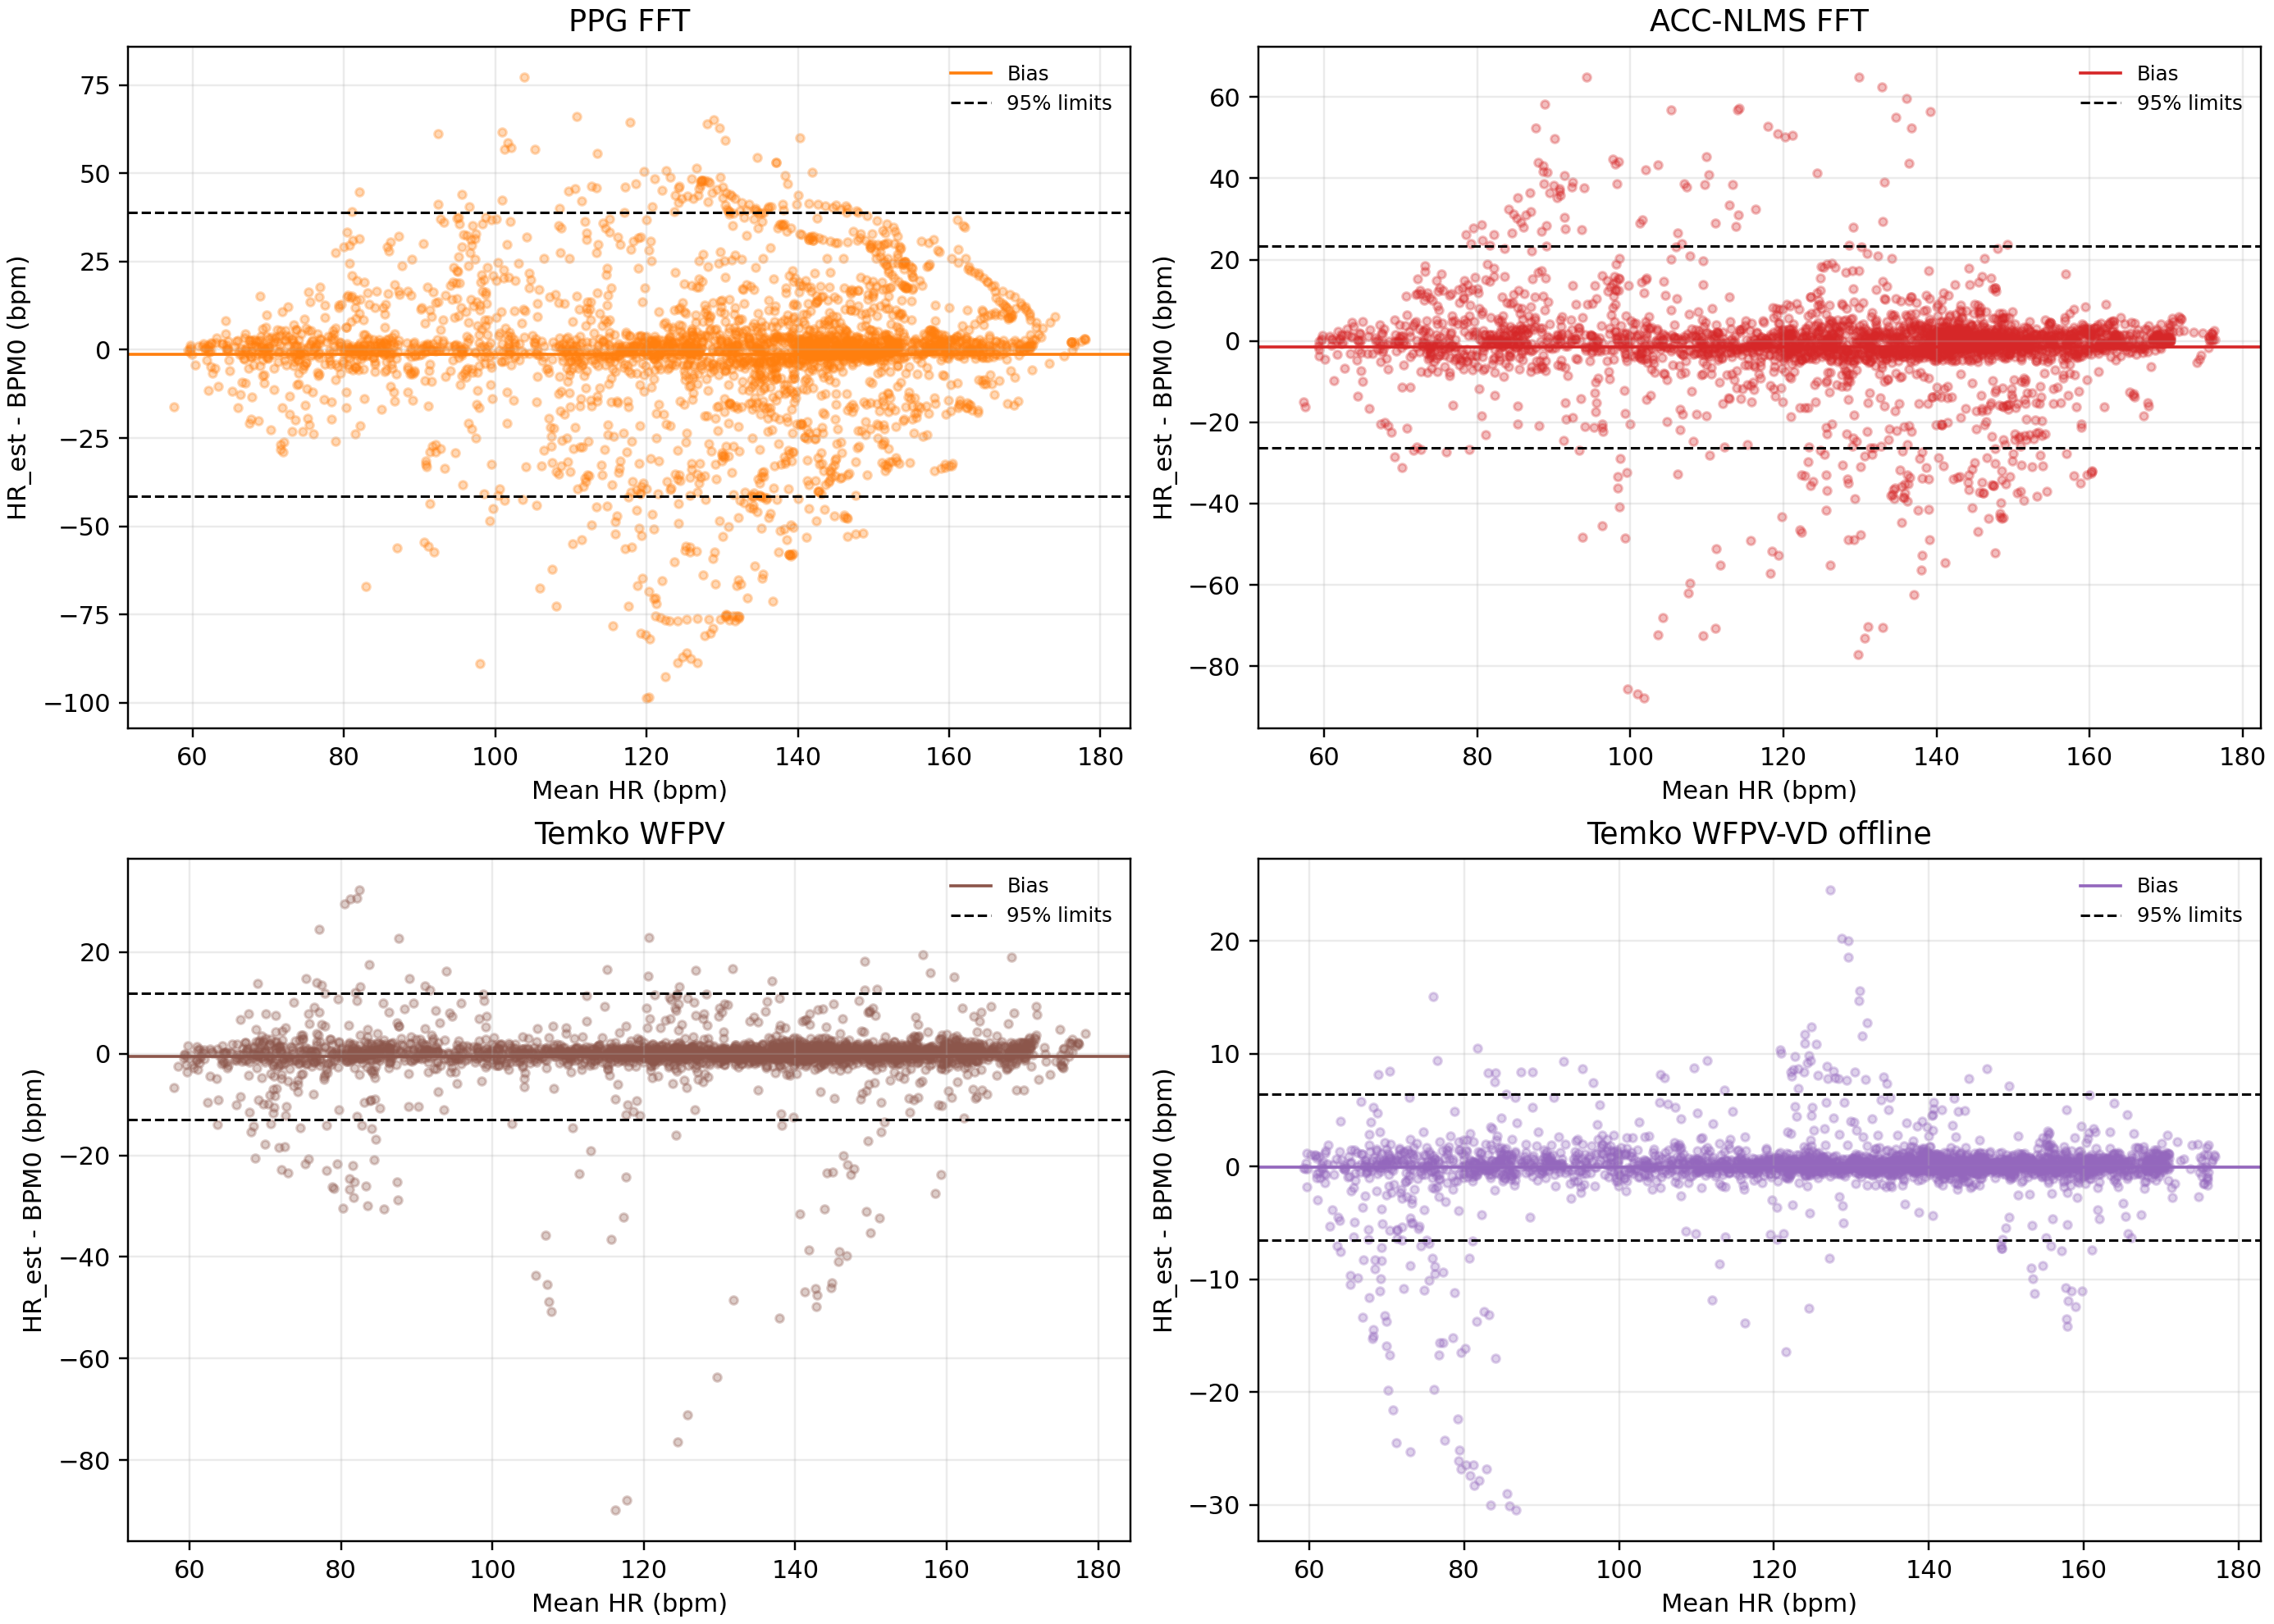

Saved: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots/bland_altman_four_methods.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 9.0), constrained_layout=True)
for ax, (method, col, color) in zip(axes.ravel(), specs):
    valid = all_windows[["hr_true_bpm", col]].dropna()
    mean_hr = valid.mean(axis=1)
    diff_hr = valid[col] - valid["hr_true_bpm"]
    ax.scatter(mean_hr, diff_hr, s=10, alpha=0.30, color=color)
    row = all_metrics[(all_metrics["record"] == "ALL_DATABASE") & (all_metrics["method"] == method)].iloc[0]
    bias = float(row["bias_bpm"])
    lower = float(row["bland_altman_lower_bpm"])
    upper = float(row["bland_altman_upper_bpm"])
    ax.axhline(bias, color=color, linewidth=1.2, label="Bias")
    ax.axhline(lower, color="black", linestyle="--", linewidth=1.0, label="95% limits")
    ax.axhline(upper, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(method)
    ax.set_xlabel("Mean HR (bpm)")
    ax.set_ylabel("HR_est - BPM0 (bpm)")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

ba_path = PLOTS_DIR / "bland_altman_four_methods.png"
fig.savefig(ba_path, dpi=220)
plt.close(fig)

display(Image(filename=str(ba_path), width=1000))
print("Saved:", ba_path)

## 15. Output File

In [16]:
print("Four-method metric table:", OUTDIR / "four_methods_avAE_avRE_sdAE_table.csv")
print("Ultimate comparison table:", OUTDIR / "ultimate_four_method_comparison_table.csv")
print("Four-method window-level results:", OUTDIR / "four_methods_window_level_results.csv")
print("PPG/ACC-NLMS metrics:", OUTDIR / "ppg_nlms_acc_fft_metrics.csv")
print("Temko WFPV metrics:", OUTDIR / "temko_wfpv_database_metrics.csv")
print("Temko WFPV-VD offline metrics:", OUTDIR / "temko_wfpv_vd_database_metrics.csv")
print("Plots directory:", PLOTS_DIR)

Four-method metric table: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/four_methods_avAE_avRE_sdAE_table.csv
Ultimate comparison table: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ultimate_four_method_comparison_table.csv
Four-method window-level results: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/four_methods_window_level_results.csv
PPG/ACC-NLMS metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/ppg_nlms_acc_fft_metrics.csv
Temko WFPV metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/temko_wfpv_database_metrics.csv
Temko WFPV-VD offline metrics: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/temko_wfpv_vd_database_metrics.csv
Plots directory: /Users/xiongzaizai/Documents/PPG/outputs_ppg_denoising_notebook/plots
